In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
import kagglehub
import os
import osmnx as ox
import geopandas as gpd
from pathlib import Path
from pandas import DataFrame

plt.style.use("default")
plt.style.use("fivethirtyeight")
#plt.style.use('seaborn-v0_8-whitegrid')


In [2]:
project_report_images_path = Path( '../../ProjectReport/Images/' )
project_report_tables_path = Path( '../../ProjectReport/Tables/' )
data_path = Path( '../data' )

In [3]:
apartments = pd.read_csv( data_path / "apartments.csv" )
apartments

,price_numeric,municipality,condition,ad_type,rooms,square_m2,equipment,level,heating,price_per_m2,latitude,longitude
0,80.0,Sarajevo - Novo Sarajevo,Renovated,Rent,2.0,62.0,Furnished,16,District Heating,1.290323,43.850305,18.374470
1,100.0,Vogošća,New Build,Rent,2.0,20.0,Furnished,-1,Central (Boiler Room),5.000000,43.901206,18.354117
2,160.0,Trnovo,New Build,Rent,2.0,50.0,Furnished,0,Electric Heating,3.200000,43.714503,18.288786
3,200.0,Sarajevo - Novi Grad,Good Condition,Rent,1.0,30.0,Furnished,1,Central (Boiler Room),6.666667,43.800453,18.246421
4,250.0,Sarajevo - Novo Sarajevo,Good Condition,Rent,2.0,48.0,Unfurnished,0,Electric Heating,5.208333,43.858893,18.399583
...,...,...,...,...,...,...,...,...,...,...,...,...
849,1000000.0,Sarajevo - Centar,Good Condition,Sale,3.0,124.0,Unfurnished,0,Gas Heating,8064.516129,43.853746,18.404423
850,1050000.0,Sarajevo - Novi Grad,New Build,Sale,4.0,146.0,Furnished,8,Central (Boiler Room),7191.780822,43.846929,18.374245
851,1191000.0,Sarajevo - Novo Sarajevo,New Build,Sale,4.0,203.0,Furnished,9,District Heating,5866.995074,43.846926,18.374029
852,1191000.0,Sarajevo - Novi Grad,New Build,Sale,4.0,203.0,Furnished,9,District Heating,5866.995074,43.847530,18.375606


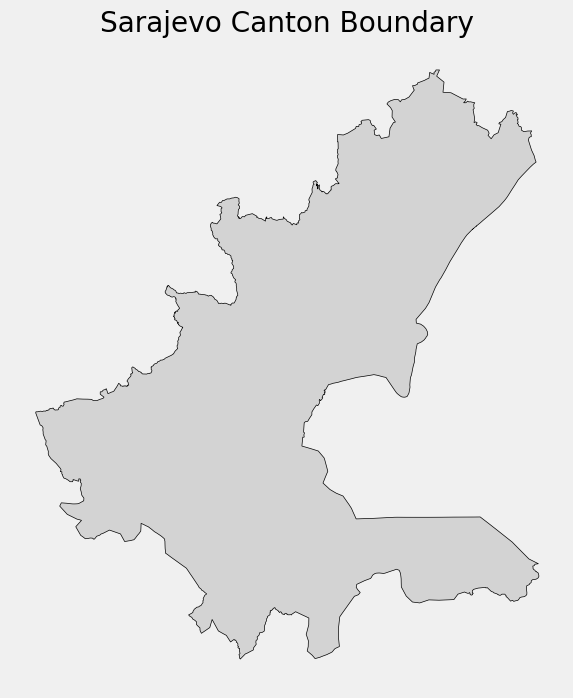

EPSG:32634


In [4]:
place = "Sarajevo Canton, Bosnia and Herzegovina"

canton = ox.geocode_to_gdf(place).to_crs(epsg=32634)

fig, ax = plt.subplots(figsize=(8, 8))
canton.plot(ax=ax, facecolor="lightgrey", edgecolor="black")
ax.set_title("Sarajevo Canton Boundary")
ax.axis("off")
plt.show()

print(canton.crs)

In [5]:
municipalities_gdf = ox.features_from_place(
  place,
  tags={'boundary' : 'administrative'}
).to_crs(epsg=32634)

municipalities_gdf = municipalities_gdf[
    (municipalities_gdf["admin_level"] == "7") &
    (municipalities_gdf.geometry.type.isin(["Polygon", "MultiPolygon"]))
].copy()

municipalities_gdf["municipality"] = (
    municipalities_gdf.get("name:bs")
    .fillna(municipalities_gdf["name"])
)

municipalities_gdf.dropna(how="any", axis="columns", inplace=True)
municipalities_gdf = municipalities_gdf.clip(canton)

municipalities_gdf = municipalities_gdf[
    municipalities_gdf.geometry.type.isin(["Polygon", "MultiPolygon"])
][['municipality', 'geometry']].copy()

municipalities_gdf.explore()

In [6]:
mapper = {
  'Sarajevo - Centar' : 'Općina Centar',
  'Sarajevo - Novo Sarajevo' : 'Općina Novo Sarajevo',
  'Sarajevo - Novi Grad' : 'Općina Novi Grad',
  'Sarajevo - Stari Grad' : 'Općina Stari Grad',
  'Ilidža' : 'Općina Ilidža',
  'Trnovo' : 'Općina Trnovo (FBiH)',
  'Vogošća' : 'Općina Vogošća'
}

apartments.replace({'municipality' : mapper}, inplace=True)

In [7]:
apartments_gdf = gpd.GeoDataFrame(
    apartments,
    geometry=gpd.points_from_xy(apartments['longitude'], apartments['latitude'], crs="EPSG:4326"),
    crs="EPSG:4326"
).to_crs("EPSG:32634")

apartments_clipped = apartments_gdf.clip(canton)

In [8]:
apartments_with_municipality = gpd.sjoin(
  left_df=apartments_clipped,
  right_df=municipalities_gdf,
  how="left",
  predicate="within",
)

corrected_apartments = apartments_with_municipality[
  apartments_with_municipality['municipality_left'] == apartments_with_municipality['municipality_right']
]

corrected_apartments.explore()

In [9]:
removed = apartments_with_municipality[
  apartments_with_municipality['municipality_left'] != apartments_with_municipality['municipality_right']
].rename(columns={'municipality_left' : 'municipality'})

removed['original_index'] = removed.index.values
removed = removed.merge(
    municipalities_gdf[["municipality", "geometry"]]
        .rename(columns={"geometry": "claimed_geom"}),
    on="municipality",
    how="left"
)

removed["dist_to_claimed_m"] = removed.geometry.distance(removed["claimed_geom"])

m = municipalities_gdf.explore(
  color="black",
  style_kwds={"fillOpacity": 0},
  name="Municipalities"
)

removed[['municipality', 'municipality_right', 'dist_to_claimed_m', 'geometry']].explore(
  m=m,
  color="red",
  marker_kwds={"radius": 6},
  name="Removed apartments"
)

m


In [10]:
for limiting_distance in [50, 100, 200, 300]:
    apartments_close = (removed['dist_to_claimed_m'] <= limiting_distance).sum()
    apartments_far = (removed['dist_to_claimed_m'] > limiting_distance).sum()

    plt.figure(figsize=(8, 5))
    plt.pie(x = [apartments_close, apartments_far], labels = [f"<={limiting_distance}", f">{limiting_distance}"], autopct="%1.1f%%")
    plt.title("Distributions of removed apartments close to border")
    plt.savefig(project_report_images_path / f"distribution_of_removed_apartments_close_to_border_pie_{limiting_distance}.pdf")
    plt.close()

In [11]:
close_removed = removed[removed['dist_to_claimed_m'] <= 300]
m = municipalities_gdf.explore(
  color="black",
  style_kwds={"fillOpacity": 0},
  name="Municipalities"
)

close_removed.explore(
  m = m,
  color="red",
  marker_kwds={"radius": 6},
  name="Removed apartments"
)

In [12]:
apartments_with_municipality.loc[close_removed['original_index'], "municipality_left"]  = apartments_with_municipality.loc[close_removed['original_index'], "municipality_right"]
corrected_apartments = apartments_with_municipality[
   apartments_with_municipality['municipality_left'] == apartments_with_municipality['municipality_right']
].copy()

corrected_apartments.drop(labels=["municipality_right", 'element', 'id'], axis="columns", inplace=True)
corrected_apartments.rename(columns={'municipality_left' : 'municipality'}, inplace=True)

In [13]:
corrected_apartments

,price_numeric,municipality,condition,ad_type,rooms,square_m2,equipment,level,heating,price_per_m2,latitude,longitude,geometry
601,325000.0,Općina Stari Grad,Partially Renovated,Sale,3.0,68.0,Unfurnished,2,Other,4779.411765,43.854715,18.432122,POINT (293618.085 4858941.876)
655,350000.0,Općina Stari Grad,Good Condition,Sale,3.0,60.0,Unfurnished,1,Gas Heating,5833.333333,43.855029,18.430080,POINT (293455.049 4858981.854)
228,1300.0,Općina Stari Grad,Good Condition,Rent,3.0,100.0,Furnished,2,Gas Heating,13.000000,43.855539,18.431140,POINT (293542.004 4859035.851)
319,125000.0,Općina Centar,Good Condition,Sale,1.0,37.0,Semi-Furnished,4,Central Gas Heating,3378.378378,43.849781,18.418039,POINT (292469.074 4858429.126)
210,1200.0,Općina Centar,Renovated,Rent,3.0,80.0,Furnished,2,Electric Heating,15.000000,43.853876,18.417133,POINT (292410.464 4858886.231)
...,...,...,...,...,...,...,...,...,...,...,...,...,...
450,247000.0,Općina Vogošća,Renovated,Sale,3.0,73.0,Unfurnished,3,Central Gas Heating,3383.561644,43.904932,18.345299,POINT (286819.124 4864739.991)
313,92500.0,Općina Vogošća,New Build,Sale,2.0,21.3,Unfurnished,6,Gas Heating,4342.723005,43.906295,18.346632,POINT (286931.037 4864887.94)
329,149500.0,Općina Vogošća,New Build,Sale,2.0,40.0,Furnished,1,Electric Heating,3737.500000,43.906398,18.346235,POINT (286899.524 4864900.405)
371,197000.0,Općina Ilidža,Renovated,Sale,2.0,43.0,Furnished,4,Central (Boiler Room),4581.395349,43.856394,18.298623,POINT (282894.467 4859470.438)


In [14]:
minx, miny, maxx, maxy = canton.total_bounds

plt.subplots(figsize=(16, 8), nrows=1, ncols=2)

ax = plt.subplot(1,2,1)
canton.plot(ax=ax, facecolor="lightgrey", edgecolor="black")
apartments_gdf.plot(
    ax=ax,
    color="red",
    markersize=6,
    alpha=0.6
)
ax.set_xlim(minx, maxx)
ax.set_ylim(miny, maxy)
ax.set_title("Distributions of all apartments")
ax.axis("off")

ax = plt.subplot(1,2,2)
canton.plot(ax=ax, facecolor="lightgrey", edgecolor="black")
corrected_apartments.plot(
    ax=ax,
    color="red",
    markersize=6,
    alpha=0.6
)

# Force view to canton extent
ax.set_xlim(minx, maxx)
ax.set_ylim(miny, maxy)
ax.set_title("Distributions of corrected apartments")
ax.axis("off")

plt.suptitle("Apartment Locations in Canton Sarajevo")
plt.close()


In [15]:
plt.subplots(figsize=(16, 8), nrows=1, ncols=2)

ax = plt.subplot(1,2,1)
canton.plot(ax=ax, facecolor="lightgrey", edgecolor="black")
corrected_apartments[apartments_clipped['ad_type'] == 'Rent'].plot(
  ax=ax,
  color="red",
  markersize=6,
  alpha=0.6
)
ax.set_title("Rentals Locations in Canton Sarajevo")
ax.set_xlim(minx, maxx)
ax.set_ylim(miny, maxy)
ax.axis("off")

ax = plt.subplot(1,2,2)
canton.plot(ax=ax, facecolor="lightgrey", edgecolor="black")
corrected_apartments[apartments_clipped['ad_type'] == 'Sale'].plot(
  ax=ax,
  color="red",
  markersize=6,
  alpha=0.6
)

# Force view to canton extent
ax.set_title("Sales Locations in Canton Sarajevo")
ax.set_xlim(minx, maxx)
ax.set_ylim(miny, maxy)
ax.axis("off")

plt.suptitle("Apartment Locations in Canton Sarajevo")

plt.savefig(project_report_images_path / "distribution_of_apartments.pdf")
plt.close()

/Users/emrearapcic-uevak/PycharmProjects/EE418-Introduction-to-Machine-Learning-Project/.venv/lib/python3.14/site-packages/geopandas/geodataframe.py:1896: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  result = super().__getitem__(key)
/Users/emrearapcic-uevak/PycharmProjects/EE418-Introduction-to-Machine-Learning-Project/.venv/lib/python3.14/site-packages/geopandas/geodataframe.py:1896: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  result = super().__getitem__(key)


In [16]:
POI_TAGS = {
    # Healthcare
    "hospital": {"amenity": "hospital"},
    "clinic": {"amenity": "clinic"},
    "pharmacy": {"amenity": "pharmacy"},

    # Education
    "school": {"amenity": "school"},
    "university": {"amenity": "university"},
    "kindergarten": {"amenity": "kindergarten"},

    # Transport
    "bus_stop": {"highway": "bus_stop"},
    "tram_stop": {"railway": "tram_stop"},
    "train_station": {"railway": "station"},
    "parking": {"amenity": "parking"},

    # Environment
    "park": {"leisure": "park"},
    "playground": {"leisure": "playground"},

    # Commerce
    "mall": {"shop": "mall"},
    "supermarket": {"shop": "supermarket"},
    "marketplace": {"amenity": "marketplace"},

    # Urban
    "restaurant": {"amenity": "restaurant"},
    "cafe": {"amenity": "cafe"},

    # Religion
    "place_of_worship": {"amenity": "place_of_worship"},

    # Safety & public services
    "police": {"amenity": "police"},
    "fire_station": {"amenity": "fire_station"},
    "post_office": {"amenity": "post_office"},

    # Sports & lifestyle
    "sports_centre": {"leisure": "sports_centre"},
    "fitness_centre": {"leisure": "fitness_centre"},
    "stadium": {"leisure": "stadium"},
}

In [17]:
poi_data = {}

for name, tags in POI_TAGS.items():
    gdf = ox.features.features_from_place(place, tags).to_crs(epsg=32634)
    # Keep only points (some POIs are polygons)
    gdf = gdf[gdf.geometry.type.isin(["Point", "Polygon"])]

    # Convert polygons to centroids
    gdf["geometry"] = gdf.geometry.centroid

    poi_data[name] = gdf

In [18]:
for feature in poi_data.keys():
    plt.figure(figsize=(10, 8))
    ax = canton.plot(facecolor="lightgrey", edgecolor="black")
    poi_data[feature].plot(ax=ax, color="red", markersize=6, alpha=0.6)
    ax.set_xlim(minx, maxx);ax.set_ylim(miny, maxy);ax.axis("off")
    plt.title(f"Distribution of {feature}s")

    plt.savefig(project_report_images_path / f"distribution_of_{feature}s.pdf")
    plt.close()

/Users/emrearapcic-uevak/PycharmProjects/EE418-Introduction-to-Machine-Learning-Project/.venv/lib/python3.14/site-packages/geopandas/plotting.py:656: RuntimeWarning: More than 20 figures have been opened. Figures created through the pyplot interface (`matplotlib.pyplot.figure`) are retained until explicitly closed and may consume too much memory. (To control this warning, see the rcParam `figure.max_open_warning`). Consider using `matplotlib.pyplot.close()`.
  fig, ax = plt.subplots(figsize=figsize)
/var/folders/0c/_nswk8qx52s9mwd15r_1fzy80000gn/T/ipykernel_58496/3022227815.py:2: RuntimeWarning: More than 20 figures have been opened. Figures created through the pyplot interface (`matplotlib.pyplot.figure`) are retained until explicitly closed and may consume too much memory. (To control this warning, see the rcParam `figure.max_open_warning`). Consider using `matplotlib.pyplot.close()`.
  plt.figure(figsize=(10, 8))


<Figure size 1000x800 with 0 Axes>

<Figure size 1000x800 with 0 Axes>

<Figure size 1000x800 with 0 Axes>

<Figure size 1000x800 with 0 Axes>

...

<Figure size 1000x800 with 0 Axes>

<Figure size 1000x800 with 0 Axes>

<Figure size 1000x800 with 0 Axes>

<Figure size 1000x800 with 0 Axes>

<Figure size 1000x800 with 0 Axes>

In [19]:
#poi_data['university'].dropna(axis="columns", how="any").explore()

In [20]:
(corrected_apartments['ad_type'] == 'Sale').sum()

np.int64(498)

In [21]:
from shapely.geometry import Point

def compute_distance(s : pd.Series):
    # Create point in WGS84
    point = Point(s["longitude"], s["latitude"])
    point = gpd.GeoSeries([point], crs="EPSG:4326").to_crs(epsg=32634).iloc[0]

    for poi_name, pois in poi_data.items():
        if pois.empty:
            s[f"closest_{poi_name}_m"] = np.nan
            continue

        idx = pois.sindex.nearest(point, 1)[1][0]
        nearest_geom = pois.geometry.iloc[idx]

        s[f"closest_{poi_name}_m"] = point.distance(nearest_geom)

    return s

apartments = corrected_apartments.apply(compute_distance, axis="columns")

In [22]:
apartments

,price_numeric,municipality,condition,ad_type,rooms,square_m2,equipment,level,heating,price_per_m2,...,closest_marketplace_m,closest_restaurant_m,closest_cafe_m,closest_place_of_worship_m,closest_police_m,closest_fire_station_m,closest_post_office_m,closest_sports_centre_m,closest_fitness_centre_m,closest_stadium_m
601,325000.0,Općina Stari Grad,Partially Renovated,Sale,3.0,68.0,Unfurnished,2,Other,4779.411765,...,560.473859,172.844470,226.154219,90.282687,736.653591,572.353702,503.767866,151.395357,2860.953083,2842.814819
655,350000.0,Općina Stari Grad,Good Condition,Sale,3.0,60.0,Unfurnished,1,Gas Heating,5833.333333,...,451.094662,256.145086,267.580371,83.591642,650.775290,530.232391,395.779379,123.030399,2742.613436,2708.940452
228,1300.0,Općina Stari Grad,Good Condition,Rent,3.0,100.0,Furnished,2,Gas Heating,13.000000,...,440.204109,154.128618,284.994870,51.287602,621.465167,471.430860,383.451437,180.464611,2740.914172,2721.929302
319,125000.0,Općina Centar,Good Condition,Sale,1.0,37.0,Semi-Furnished,4,Central Gas Heating,3378.378378,...,1111.526540,583.569145,630.331904,253.721164,871.069294,614.904167,798.565408,658.440402,2956.470790,2481.958240
210,1200.0,Općina Centar,Renovated,Rent,3.0,80.0,Furnished,2,Electric Heating,15.000000,...,758.966705,178.239009,171.229997,222.462530,410.343216,172.557712,392.070128,235.441189,2495.623467,2314.706444
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
450,247000.0,Općina Vogošća,Renovated,Sale,3.0,73.0,Unfurnished,3,Central Gas Heating,3383.561644,...,359.098293,537.715498,299.552701,666.571476,397.221499,1025.546130,468.102477,591.627851,6260.591872,678.642163
313,92500.0,Općina Vogošća,New Build,Sale,2.0,21.3,Unfurnished,6,Gas Heating,4342.723005,...,544.543335,678.884794,484.888298,765.199194,575.540765,1047.910242,638.430539,774.170318,6250.183740,822.716515
329,149500.0,Općina Vogošća,New Build,Sale,2.0,40.0,Furnished,1,Electric Heating,3737.500000,...,537.168744,690.958880,478.064830,785.718476,575.176363,1078.079023,641.838310,771.028058,6283.238759,834.504175
371,197000.0,Općina Ilidža,Renovated,Sale,2.0,43.0,Furnished,4,Central (Boiler Room),4581.395349,...,57.701735,2311.760026,2696.348449,722.138992,612.553541,2126.445926,2071.066402,2878.140221,3185.474237,4998.314810


In [23]:
apartments.drop(labels=["latitude", "longitude", "geometry"], axis=1, inplace=True)

sales = apartments[apartments['ad_type'] == 'Sale'].drop(labels="ad_type", axis=1)
sales.to_csv(data_path / "sales.csv", index=False)

rentals = apartments[apartments['ad_type'] == 'Rent'].drop(labels="ad_type", axis=1)
rentals.to_csv("../data/rentals.csv", index=False)

In [24]:
for column, column_type in apartments.dtypes.items():
  if column == "ad_type": continue

  if column_type  == 'object':
    plt.figure(figsize=(5, 4))
    sns.countplot(data=apartments, y = column, order=apartments[column].value_counts().index.values, hue="ad_type")
    plt.savefig(project_report_images_path / f"count_plot_of_{column}_via_ad_type.pdf", bbox_inches="tight")
  else:
    fig, axes = plt.subplots(nrows = 1, ncols=2, figsize=(12, 3), sharex=True)

    sns.histplot(data=apartments, x = column, hue='ad_type', kde=True, ax=axes[0])
    sns.boxplot(data=apartments, x = column, hue='ad_type', ax=axes[1])

    fig.savefig(project_report_images_path / f"distribution_of_{column}.pdf", bbox_inches="tight")

  plt.close()


In [25]:
rentals = apartments[apartments['ad_type'] == 'Rent']
sales = apartments[apartments['ad_type'] == 'Sale']

rental_equipment =  rentals['equipment'].value_counts()
sales_equipment = sales['equipment'].value_counts()


default_colors = plt.rcParams["axes.prop_cycle"].by_key()["color"]
category_colors = {
  'Furnished' : default_colors[0],
  'Semi-Furnished' : default_colors[1],
  'Unfurnished' : default_colors[2]
}


plt.subplots(nrows = 1, ncols = 2, figsize=(10, 5))

plt.subplot(1, 2, 1)
plt.pie(x = rental_equipment, labels=rental_equipment.index.values, autopct='%.1f%%', colors=[category_colors[cat] for cat in rental_equipment.index.values])
plt.title('Rental equipment', pad=12)

plt.subplot(1, 2, 2)
plt.pie(x = sales_equipment, labels = sales_equipment.index.values, autopct='%.1f%%', colors=[category_colors[cat] for cat in sales_equipment.index.values])
plt.title('Sales equipment', pad=12)

plt.tight_layout()
plt.suptitle('Equipment distribution')

plt.savefig(project_report_images_path / "equipment_distribution_pie.pdf", bbox_inches="tight")
plt.close()